# Anomaly Detection

Objective:
- Detect abnormal consumption patterns
- Use unsupervised learning
- Compare anomaly scores with theft labels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_v2.csv")

df.head()

,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,...,lag_1,lag_24,diff_1,diff_24,z_score,transformer_deviation,is_peak_hour,rolling_max_24h,rolling_min_24h,sudden_drop_flag
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,...,0.000000,0.0,0.000000,0.0,0.000000,-0.008255,0,1.408501,1.408501,0
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,...,1.408501,0.0,0.182400,0.0,0.707101,-0.006012,0,1.590901,1.408501,0
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,...,1.590901,0.0,-0.051072,0.0,0.284302,-0.007800,0,1.590901,1.408501,0
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,...,1.539829,0.0,-0.324576,0.0,-1.333025,-0.015873,0,1.590901,1.215253,0
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,...,1.215253,0.0,0.916079,0.0,1.619930,0.000783,0,2.131333,1.215253,0


In [3]:
feature_columns = [
    "kwh",
    "voltage",
    "current",
    "power_factor",
    "temperature",
    "humidity",
    "load_ratio",
    "rolling_mean_24h",
    "rolling_std_24h",
    "lag_1",
    "lag_24",
    "z_score",
    "transformer_deviation"
]

X = df[feature_columns]
y = df["theft_label"]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_scaled)

iso_scores = iso_model.decision_function(X_scaled)
iso_predictions = iso_model.predict(X_scaled)

# Convert predictions: -1 (anomaly) → 1, 1 (normal) → 0
iso_predictions = np.where(iso_predictions == -1, 1, 0)

df["isolation_anomaly_flag"] = iso_predictions
df["isolation_score"] = -iso_scores

In [6]:
print("Isolation Forest Classification Report:\n")
print(classification_report(y, df["isolation_anomaly_flag"]))

roc_iso = roc_auc_score(y, df["isolation_score"])
print("Isolation Forest ROC-AUC:", roc_iso)

Isolation Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98    287473
           1       0.04      0.98      0.07       527

    accuracy                           0.95    288000
   macro avg       0.52      0.97      0.52    288000
weighted avg       1.00      0.95      0.97    288000

Isolation Forest ROC-AUC: 0.9895130024289187


In [7]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_predictions = lof_model.fit_predict(X_scaled)

lof_predictions = np.where(lof_predictions == -1, 1, 0)

df["lof_anomaly_flag"] = lof_predictions

In [8]:
print("LOF Classification Report:\n")
print(classification_report(y, df["lof_anomaly_flag"]))

LOF Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    287473
           1       0.01      0.36      0.03       527

    accuracy                           0.95    288000
   macro avg       0.51      0.66      0.50    288000
weighted avg       1.00      0.95      0.97    288000



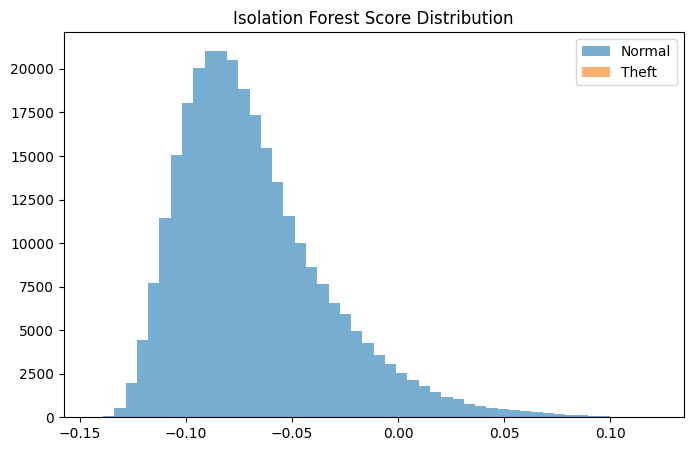

In [9]:
normal_iso = df[df["theft_label"] == 0]["isolation_score"]
theft_iso = df[df["theft_label"] == 1]["isolation_score"]

plt.figure(figsize=(8,5))
plt.hist(normal_iso, bins=50, alpha=0.6, label="Normal")
plt.hist(theft_iso, bins=50, alpha=0.6, label="Theft")
plt.legend()
plt.title("Isolation Forest Score Distribution")
plt.show()

In [10]:
threshold = np.percentile(normal_iso, 95)

df["optimized_iso_flag"] = (
    df["isolation_score"] > threshold
).astype(int)

print("Optimized Threshold:", threshold)

print(classification_report(y, df["optimized_iso_flag"]))

Optimized Threshold: -0.0009282051078942479
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    287473
           1       0.03      0.98      0.07       527

    accuracy                           0.95    288000
   macro avg       0.52      0.97      0.52    288000
weighted avg       1.00      0.95      0.97    288000



In [11]:
corr = df[["isolation_score", "theft_label"]].corr()

print("Correlation with Theft:")
print(corr)

Correlation with Theft:
                 isolation_score  theft_label
isolation_score         1.000000     0.143487
theft_label             0.143487     1.000000


In [12]:
df.to_csv("../data/processed/feature_engineered_with_anomaly.csv", index=False)

print("Dataset with anomaly features saved.")

Dataset with anomaly features saved.


## Anomaly Detection Summary

1. Isolation Forest identifies abnormal consumption patterns.
2. LOF provides neighborhood-based anomaly detection.
3. Anomaly scores correlate with theft cases.
4. These anomaly features can be combined with supervised models.

Next Step:
- Train supervised classification model
- Build ensemble risk scoring system